# Módulo 3 — Navegación 

Un agente quiere ir desde `(0, 0)` hasta la esquina superior derecha gastando el menor tiempo posible.

Este notebook reproduce, con una sola representación del problema:

1. **Iteración de valor** e **iteración de política** (conocemos el modelo).
2. **Monte Carlo** y **TD(0)** (Monte Carlo con bootstrapping), donde evaluamos una política fija.
3. **Q-learning** (aprendemos la política óptima sin conocer el modelo).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

rng = np.random.default_rng(7)  # resultados reproducibles

ANCHO = ALTO = 8
ACCIONES = {
    "N": (0, 1), "S": (0, -1),
    "O": (-1, 0), "E": (1, 0),
}
ESTADOS = [(x, y) for x in range(ANCHO) for y in range(ALTO)]
META = (ANCHO - 1, ALTO - 1)


def acciones_validas(estado):
    x, y = estado
    return [a for a, (dx, dy) in ACCIONES.items()
            if 0 <= x + dx < ANCHO and 0 <= y + dy < ALTO]


def siguiente(estado, accion):
    dx, dy = ACCIONES[accion]
    return (estado[0] + dx, estado[1] + dy)


def calle(estado, proximo):
    # Una calle tiene la misma clave en ambos sentidos.
    return tuple(sorted((estado, proximo)))


# Cada calle tiene un tiempo medio y una variación aleatoria diaria.
CALLES = sorted({calle(s, siguiente(s, a)) for s in ESTADOS for a in acciones_validas(s)})
TIEMPO_MEDIO = {c: rng.integers(5, 10) for c in CALLES}
RANGO = {c: rng.integers(1, 5) for c in CALLES}


def costo(estado, accion, tiempo_real=None):
    c = calle(estado, siguiente(estado, accion))
    return (TIEMPO_MEDIO if tiempo_real is None else tiempo_real)[c]


def nuevo_dia():
    # Genera una realización nueva de los tiempos de viaje.
    return {c: rng.uniform(TIEMPO_MEDIO[c] - RANGO[c],
                           TIEMPO_MEDIO[c] + RANGO[c]) for c in CALLES}


def mostrar_politica(politica, titulo):
    simbolo = {"N": "↑", "S": "↓", "O": "←", "E": "→"}
    dibujo = np.full((ALTO, ANCHO), "·", dtype=object)
    for (x, y), a in politica.items():
        dibujo[y, x] = simbolo[a]
    dibujo[META[1], META[0]] = "★"
    print(titulo)
    for fila in dibujo[::-1]:
        print(" ".join(fila))


print(f"Estados: {len(ESTADOS)} | Acciones: {list(ACCIONES)} | Meta: {META}")

Estados: 64 | Acciones: ['N', 'S', 'O', 'E'] | Meta: (7, 7)


## 1. Iteración de valor y iteración de politica


In [16]:
def accion_codiciosa(estado, V):
    return min(acciones_validas(estado),
               key=lambda a: costo(estado, a) + V[siguiente(estado, a)])


def iteracion_valor(tolerancia=1e-9):
    V = {s: 0.0 for s in ESTADOS}
    historial = []
    while True:
        nuevo = V.copy()
        for s in ESTADOS:
            if s != META:
                nuevo[s] = min(costo(s, a) + V[siguiente(s, a)]
                               for a in acciones_validas(s))
        error = max(abs(nuevo[s] - V[s]) for s in ESTADOS)
        historial.append(error)
        V = nuevo
        if error < tolerancia:
            break
    politica = {s: accion_codiciosa(s, V) for s in ESTADOS if s != META}
    return V, politica, historial


def evaluar_politica(politica, tolerancia=1e-9):
    V = {s: 0.0 for s in ESTADOS}
    while True:
        nuevo = V.copy()
        for s, a in politica.items():
            nuevo[s] = costo(s, a) + V[siguiente(s, a)]
        error = max(abs(nuevo[s] - V[s]) for s in ESTADOS)
        V = nuevo
        if error < tolerancia:
            return V


def iteracion_politica():
    # Política inicial que siempre avanza hacia la meta.
    politica = {s: ("E" if "E" in acciones_validas(s) else "N")
                for s in ESTADOS if s != META}
    mejoras = 0
    while True:
        V = evaluar_politica(politica)
        nueva = {s: accion_codiciosa(s, V) for s in politica}
        mejoras += 1
        if nueva == politica:
            return V, politica, mejoras
        politica = nueva

In [31]:
inicio = perf_counter()
V_vi, politica_vi, errores_vi = iteracion_valor()
tiempo_vi = perf_counter() - inicio

inicio = perf_counter()
V_pi, politica_pi, mejoras_pi = iteracion_politica()
tiempo_pi = perf_counter() - inicio

print(f"Iteración de valor: {len(errores_vi)} iteraciones, {tiempo_vi:.4f} s")
print(f"Iteración de política: {mejoras_pi} iteraciones, {tiempo_pi:.4f} s")
print(f"Mismo valor inicial: {np.isclose(V_vi[(0, 0)], V_pi[(0, 0)])}")
print(f"Tiempo óptimo esperado desde (0, 0): {V_vi[(0, 0)]:.1f}")
mostrar_politica(politica_vi, "Política óptima")



Iteración de valor: 17 iteraciones, 0.0345 s
Iteración de política: 5 iteraciones, 0.0127 s
Mismo valor inicial: True
Tiempo óptimo esperado desde (0, 0): 83.0
Política óptima
→ → → → → → → ★
→ → → → → → → ↑
↑ ↑ ↑ → → → → ↑
↑ ↑ ↑ → → → ↑ ↑
→ ↑ → → → ↑ → ↑
↑ → → → → ↑ ↑ ↑
→ → → ↑ ↑ ↑ → ↑
→ → → → ↑ ↑ ↑ ↑


## 2. Evaluar una política sin conocer el modelo

Ahora el agente solo observa transiciones `(estado, acción, costo, estado siguiente)`.

- **Monte Carlo** espera hasta el final del episodio y promedia el costo total observado.
- **TD(0)** actualiza después de cada paso usando `costo + V(estado siguiente)`.

`episodio` acepta políticas **determinísticas** (`estado → acción`) y **aleatorizadas** (`estado → {acción: probabilidad}`). Para comparar los algoritmos usaremos una política fija: ir al este mientras sea posible y luego al norte.

Repetiremos cada experimento 20 veces. Monte Carlo usa retornos completos: suele tener poco sesgo pero más varianza. TD usa *bootstrapping*: al principio tiene más sesgo porque parte de estimaciones nulas, pero suele reducir la varianza.

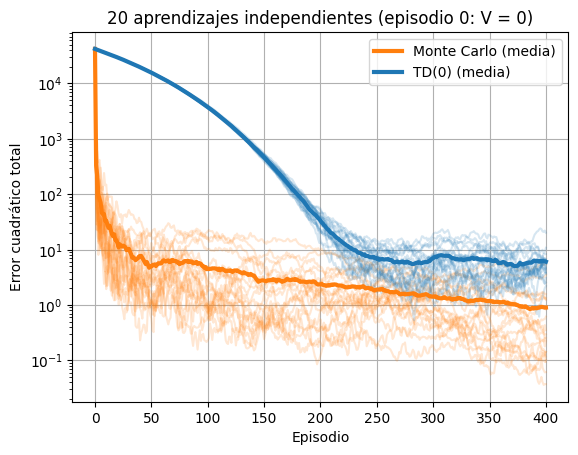

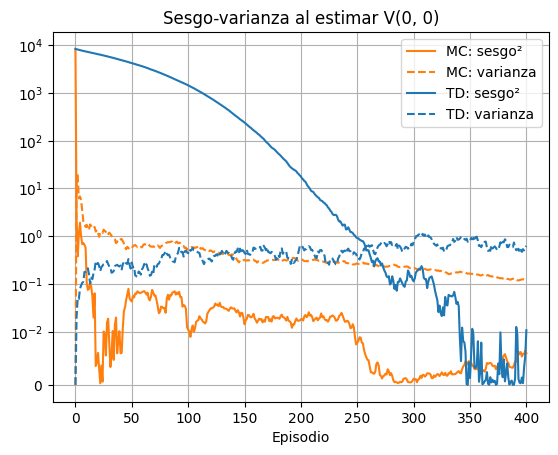

Valor real desde (0, 0): 91.0
Promedio final MC: 91.1
Promedio final TD: 90.9


In [18]:
POLITICA_FIJA = {s: ("E" if "E" in acciones_validas(s) else "N")
                  for s in ESTADOS if s != META}
V_REAL = evaluar_politica(POLITICA_FIJA)


def elegir_accion(politica, estado):
    decision = politica[estado]
    if isinstance(decision, str):       # política determinística
        return decision

    # Política aleatorizada: {acción: probabilidad}
    acciones = list(decision)
    probabilidades = np.array([decision[a] for a in acciones], dtype=float)
    probabilidades /= probabilidades.sum()
    return str(rng.choice(acciones, p=probabilidades))


def episodio(politica, inicio=(0, 0), max_pasos=10_000):
    tiempos = nuevo_dia()
    trayectoria = []
    s = inicio
    while s != META and len(trayectoria) < max_pasos:
        a = elegir_accion(politica, s)
        sp = siguiente(s, a)
        trayectoria.append((s, a, costo(s, a, tiempos), sp))
        s = sp
    if s != META:
        raise RuntimeError("El episodio no llegó a la meta.")
    return trayectoria


# Ejemplo: todas las acciones válidas tienen igual probabilidad.
POLITICA_ALEATORIA = {
    s: {a: 1 / len(acciones_validas(s)) for a in acciones_validas(s)}
    for s in ESTADOS if s != META
}


def error_total(V):
    return sum((V[s] - V_REAL[s])**2 for s in trayectoria_estados)


def monte_carlo(n_episodios):
    V = {s: 0.0 for s in ESTADOS}
    visitas = {s: 0 for s in ESTADOS}
    errores = [error_total(V)]          # episodio 0: V = 0
    estimaciones = [V[(0, 0)]]
    for _ in range(n_episodios):
        trayectoria = episodio(POLITICA_FIJA)
        retorno = 0.0
        for s, _, r, _ in reversed(trayectoria):
            retorno += r
            visitas[s] += 1
            V[s] += (retorno - V[s]) / visitas[s]
        errores.append(error_total(V))
        estimaciones.append(V[(0, 0)])
    return np.array(errores), np.array(estimaciones)


def td_cero(n_episodios, alpha=0.08):
    V = {s: 0.0 for s in ESTADOS}
    errores = [error_total(V)]          # episodio 0: V = 0
    estimaciones = [V[(0, 0)]]
    for _ in range(n_episodios):
        for s, _, r, sp in episodio(POLITICA_FIJA):
            V[s] += alpha * (r + V[sp] - V[s])
        errores.append(error_total(V))
        estimaciones.append(V[(0, 0)])
    return np.array(errores), np.array(estimaciones)


# Solo comparamos estados visitados por la política fija desde el inicio.
trayectoria_estados = [s for s, _, _, _ in episodio(POLITICA_FIJA)]
N_EPISODIOS = 400
REPETICIONES = 20
resultados_mc = [monte_carlo(N_EPISODIOS) for _ in range(REPETICIONES)]
resultados_td = [td_cero(N_EPISODIOS) for _ in range(REPETICIONES)]
errores_mc = np.array([r[0] for r in resultados_mc])
errores_td = np.array([r[0] for r in resultados_td])
estimaciones_mc = np.array([r[1] for r in resultados_mc])
estimaciones_td = np.array([r[1] for r in resultados_td])

# Cada curva fina es una repetición independiente; la gruesa es el promedio.
for curva in errores_mc:
    plt.plot(curva, color="tab:orange", alpha=0.18)
for curva in errores_td:
    plt.plot(curva, color="tab:blue", alpha=0.18)
plt.plot(errores_mc.mean(axis=0), color="tab:orange", linewidth=3, label="Monte Carlo (media)")
plt.plot(errores_td.mean(axis=0), color="tab:blue", linewidth=3, label="TD(0) (media)")
plt.yscale("log")
plt.xlabel("Episodio")
plt.ylabel("Error cuadrático total")
plt.title("20 aprendizajes independientes (episodio 0: V = 0)")
plt.legend()
plt.grid(True)
plt.show()

# Sesgo-varianza de la estimación V(0, 0) entre las repeticiones.
valor_real_inicial = V_REAL[(0, 0)]
def sesgo2_y_varianza(estimaciones):
    sesgo2 = (estimaciones.mean(axis=0) - valor_real_inicial)**2
    varianza = estimaciones.var(axis=0)
    return sesgo2, varianza

sesgo2_mc, varianza_mc = sesgo2_y_varianza(estimaciones_mc)
sesgo2_td, varianza_td = sesgo2_y_varianza(estimaciones_td)
plt.plot(sesgo2_mc, color="tab:orange", label="MC: sesgo²")
plt.plot(varianza_mc, "--", color="tab:orange", label="MC: varianza")
plt.plot(sesgo2_td, color="tab:blue", label="TD: sesgo²")
plt.plot(varianza_td, "--", color="tab:blue", label="TD: varianza")
plt.yscale("symlog", linthresh=0.01)
plt.xlabel("Episodio")
plt.title("Sesgo-varianza al estimar V(0, 0)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Valor real desde (0, 0): {valor_real_inicial:.1f}")
print(f"Promedio final MC: {estimaciones_mc[:, -1].mean():.1f}")
print(f"Promedio final TD: {estimaciones_td[:, -1].mean():.1f}")

## 3. Q-learning: aprender qué hacer

Q-learning ya no recibe una política. Explora con una estrategia **ε-greedy** y aprende el costo de cada par `(estado, acción)`.

Como minimizamos tiempos, la acción codiciosa es la de menor `Q`. Compararemos varios valores de ε; el tiempo graficado incluye las acciones exploratorias tomadas durante el entrenamiento.

Coincidencia con la política óptima (ε=0.25): 98.4%
Política aprendida por Q-learning (ε=0.25)
→ → → → → → → ★
→ → → → → → → ↑
↑ ↑ ↑ → → → → ↑
↑ ↑ ↑ → → → ↑ ↑
↑ ↑ → → → ↑ → ↑
↑ → → → → ↑ ↑ ↑
→ → → ↑ ↑ ↑ → ↑
→ → → → ↑ ↑ ↑ ↑


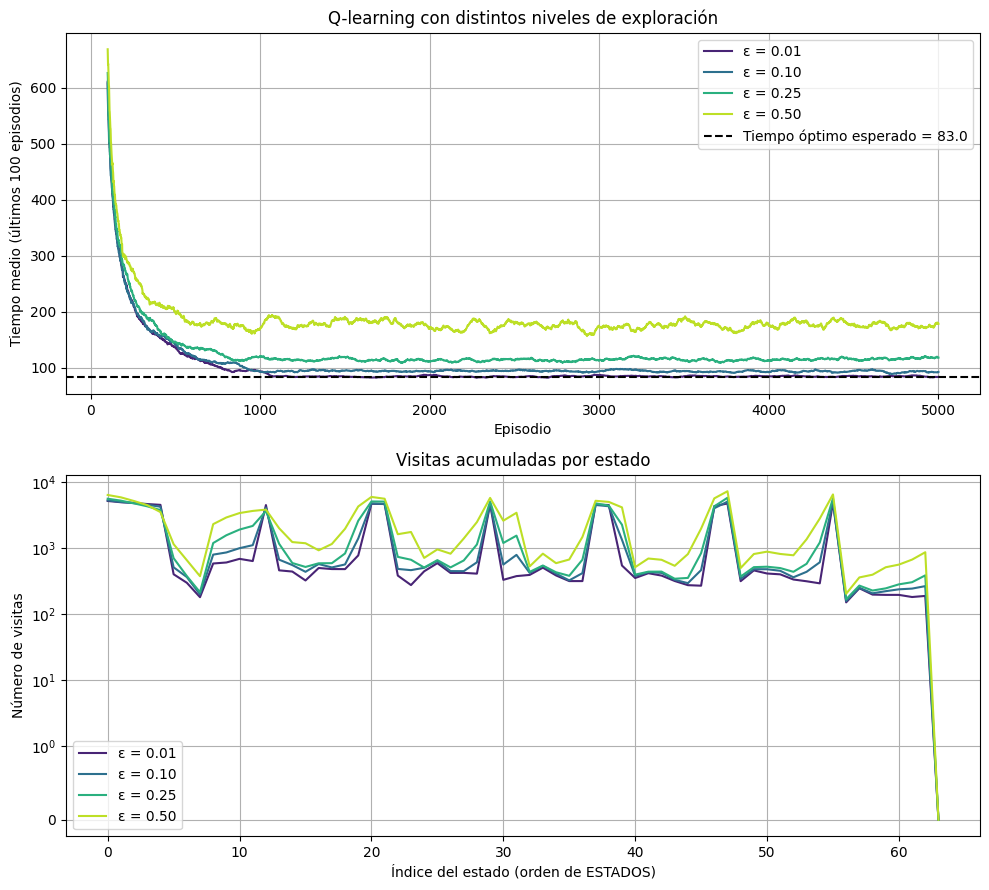

In [ ]:
def q_learning(n_episodios=10000, epsilon=0.25, alpha=0.08):
    Q = {(s, a): 0.0 for s in ESTADOS for a in acciones_validas(s)}
    visitas = {(s, a): 0 for s, a in Q}
    costo_por_episodio = []

    for _ in range(n_episodios):
        tiempos = nuevo_dia()
        s = (0, 0)
        total = 0.0
        while s != META:
            validas = acciones_validas(s)
            if rng.random() < epsilon:
                a = rng.choice(validas)
            else:
                a = min(validas, key=lambda x: Q[s, x])

            sp = siguiente(s, a)
            r = costo(s, a, tiempos)
            futuro = 0.0 if sp == META else min(Q[sp, ap] for ap in acciones_validas(sp))
            Q[s, a] += alpha * (r + futuro - Q[s, a])
            visitas[s, a] += 1
            total += r
            s = sp
        costo_por_episodio.append(total)

    politica = {s: min(acciones_validas(s), key=lambda a: Q[s, a])
                for s in ESTADOS if s != META}
    return Q, politica, visitas, costo_por_episodio


N_Q = 5000
NIVELES_EXPLORACION = [0.01, 0.10, 0.25, 0.50]
resultados_q = {
    epsilon: q_learning(n_episodios=N_Q, epsilon=epsilon)
    for epsilon in NIVELES_EXPLORACION
}

# Mostramos la política aprendida con un nivel intermedio de exploración.
Q, politica_q, visitas, costos = resultados_q[0.25]
mostrar_politica(politica_q, "Política aprendida por Q-learning (ε=0.25)")

ventana = 100
episodios = np.arange(ventana, N_Q + 1)
fig, (ax_tiempo, ax_visitas) = plt.subplots(2, 1, figsize=(10, 9))
colores = plt.cm.viridis(np.linspace(0.1, 0.9, len(resultados_q)))

for (epsilon, (_, _, visitas_epsilon, costos_epsilon)), color in zip(resultados_q.items(), colores):
    promedio = np.convolve(costos_epsilon, np.ones(ventana) / ventana, mode="valid")
    ax_tiempo.plot(episodios, promedio, color=color, label=f"ε = {epsilon:.2f}")

    visitas_por_estado = [
        sum(visitas_epsilon[s, a] for a in acciones_validas(s))
        for s in ESTADOS
    ]
    ax_visitas.plot(range(len(ESTADOS)), visitas_por_estado, color=color,
                     label=f"ε = {epsilon:.2f}")

ax_tiempo.axhline(V_vi[(0, 0)], color="black", linestyle="--",
            label=f"Tiempo óptimo esperado = {V_vi[(0, 0)]:.1f}")
ax_tiempo.set_xlabel("Episodio")
ax_tiempo.set_ylabel("Tiempo medio (últimos 100 episodios)")
ax_tiempo.set_title("Q-learning con distintos niveles de exploración")
ax_tiempo.legend()
ax_tiempo.grid(True)

ax_visitas.set_xlabel("Índice del estado (orden de ESTADOS)")
ax_visitas.set_ylabel("Número de visitas")
ax_visitas.set_title("Visitas acumuladas por estado")
ax_visitas.set_yscale("symlog", linthresh=1)
ax_visitas.legend()
ax_visitas.grid(True)

fig.tight_layout()
plt.show()

In [30]:
resultados_q[0.25][2]


{((0, 0), 'N'): 967,
 ((0, 0), 'E'): 4624,
 ((1, 0), 'N'): 583,
 ((1, 0), 'O'): 459,
 ((1, 0), 'E'): 4187,
 ((2, 0), 'N'): 551,
 ((2, 0), 'O'): 486,
 ((2, 0), 'E'): 3716,
 ((3, 0), 'N'): 516,
 ((3, 0), 'O'): 403,
 ((3, 0), 'E'): 3370,
 ((4, 0), 'N'): 2904,
 ((4, 0), 'O'): 402,
 ((4, 0), 'E'): 454,
 ((5, 0), 'N'): 400,
 ((5, 0), 'O'): 99,
 ((5, 0), 'E'): 205,
 ((6, 0), 'N'): 205,
 ((6, 0), 'O'): 70,
 ((6, 0), 'E'): 103,
 ((7, 0), 'N'): 148,
 ((7, 0), 'O'): 67,
 ((0, 1), 'N'): 398,
 ((0, 1), 'S'): 132,
 ((0, 1), 'E'): 663,
 ((1, 1), 'N'): 230,
 ((1, 1), 'S'): 119,
 ((1, 1), 'O'): 139,
 ((1, 1), 'E'): 1078,
 ((2, 1), 'N'): 385,
 ((2, 1), 'S'): 163,
 ((2, 1), 'O'): 225,
 ((2, 1), 'E'): 1136,
 ((3, 1), 'N'): 1587,
 ((3, 1), 'S'): 171,
 ((3, 1), 'O'): 181,
 ((3, 1), 'E'): 228,
 ((4, 1), 'N'): 2700,
 ((4, 1), 'S'): 291,
 ((4, 1), 'O'): 296,
 ((4, 1), 'E'): 353,
 ((5, 1), 'N'): 654,
 ((5, 1), 'S'): 180,
 ((5, 1), 'O'): 135,
 ((5, 1), 'E'): 194,
 ((6, 1), 'N'): 130,
 ((6, 1), 'S'): 106,
 ((6, 1

In [33]:
POLITICA_FIJA

{(0, 0): 'E',
 (1, 0): 'E',
 (2, 0): 'E',
 (3, 0): 'E',
 (4, 0): 'E',
 (5, 0): 'E',
 (6, 0): 'E',
 (7, 0): 'N',
 (0, 1): 'E',
 (1, 1): 'E',
 (2, 1): 'E',
 (3, 1): 'E',
 (4, 1): 'E',
 (5, 1): 'E',
 (6, 1): 'E',
 (7, 1): 'N',
 (0, 2): 'E',
 (1, 2): 'E',
 (2, 2): 'E',
 (3, 2): 'E',
 (4, 2): 'E',
 (5, 2): 'E',
 (6, 2): 'E',
 (7, 2): 'N',
 (0, 3): 'E',
 (1, 3): 'E',
 (2, 3): 'E',
 (3, 3): 'E',
 (4, 3): 'E',
 (5, 3): 'E',
 (6, 3): 'E',
 (7, 3): 'N',
 (0, 4): 'E',
 (1, 4): 'E',
 (2, 4): 'E',
 (3, 4): 'E',
 (4, 4): 'E',
 (5, 4): 'E',
 (6, 4): 'E',
 (7, 4): 'N',
 (0, 5): 'E',
 (1, 5): 'E',
 (2, 5): 'E',
 (3, 5): 'E',
 (4, 5): 'E',
 (5, 5): 'E',
 (6, 5): 'E',
 (7, 5): 'N',
 (0, 6): 'E',
 (1, 6): 'E',
 (2, 6): 'E',
 (3, 6): 'E',
 (4, 6): 'E',
 (5, 6): 'E',
 (6, 6): 'E',
 (7, 6): 'N',
 (0, 7): 'E',
 (1, 7): 'E',
 (2, 7): 'E',
 (3, 7): 'E',
 (4, 7): 'E',
 (5, 7): 'E',
 (6, 7): 'E'}